Salt & Pepper experiment with 2 fates.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from vertax import BilevelOptimizationMethod, BoundedBilevelOptimizer, BoundedMesh, FacePlot, plot_mesh
from vertax.cost import cost_checkerboard
from vertax.energy import energy_bounded

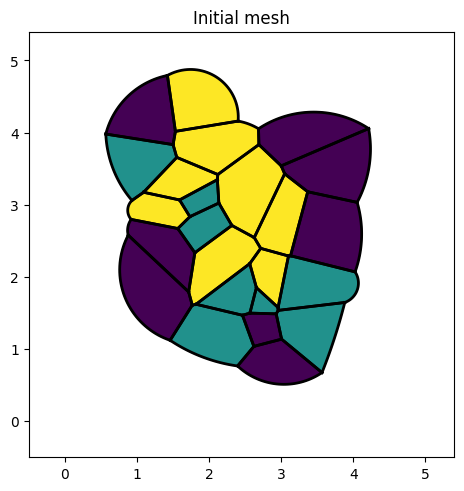

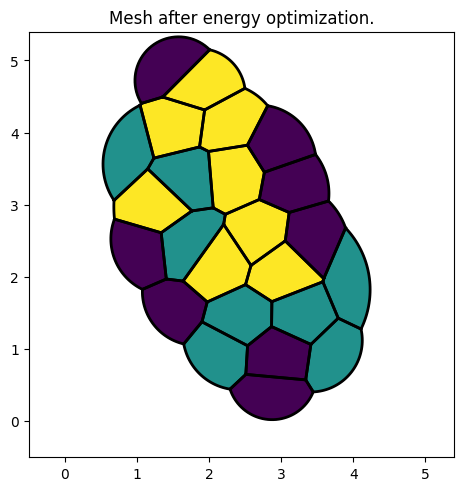

epoch: 0/10000, current cost is 5.639962196350098


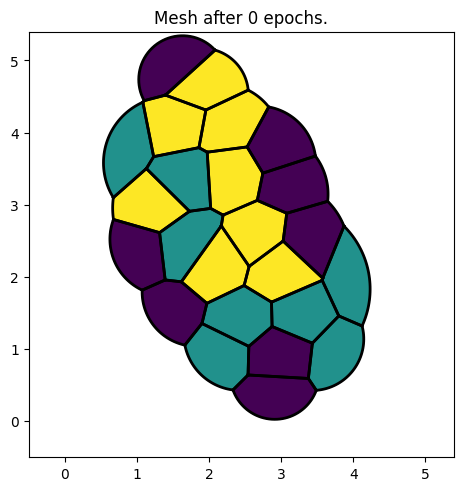

epoch: 1/10000, current cost is 5.735107421875
epoch: 2/10000, current cost is 5.7450480461120605
epoch: 3/10000, current cost is 5.73353385925293
epoch: 4/10000, current cost is 5.716999053955078
epoch: 5/10000, current cost is 5.699045181274414
epoch: 6/10000, current cost is 5.6816487312316895


In [ ]:
"""Initial configuration is created randomly."""

# Set mesh geometry
n_cells = 24
L_box = jnp.sqrt(n_cells)
width = float(L_box)
height = float(L_box)

# Create a new mesh
rng = np.random.default_rng(1337)
rng_seed = rng.integers(0, 2 ** 32 - 1)
mesh = BoundedMesh.from_random_seeds(nb_seeds=n_cells, width=width, height=height, random_key=rng_seed, nb_fates=3)
plot_mesh(mesh, title="Initial mesh", face_plot=FacePlot.FATES, faces_cmap_name="viridis")

# Initialize degrees of freedom
mesh.vertices_params = jnp.asarray([0.0 for _ in range(mesh.nb_vertices)])
key = jax.random.PRNGKey(rng_seed)
mesh.edges_params = jax.random.uniform(key, (mesh.nb_edges,))* 20 - 10
mesh.faces_params = jnp.asarray([0.0 for _ in range(mesh.nb_faces)])

# Set inner optimization hyperparameters
bilevel_optimizer = BoundedBilevelOptimizer()
bilevel_optimizer.inner_solver = optax.sgd(learning_rate=0.01)
bilevel_optimizer.update_T1 = True
bilevel_optimizer.min_dist_T1 = 0.025
bilevel_optimizer.max_nb_iterations = 1000
bilevel_optimizer.tolerance = 1e-6
bilevel_optimizer.patience = 5
bilevel_optimizer.loss_function_inner = energy_bounded

# Perform energy optimization
loss_history = bilevel_optimizer.inner_optimization(mesh)
plot_mesh(mesh, title="Mesh after energy optimization.", face_plot=FacePlot.FATES, faces_cmap_name="viridis")

# Set outer optimization hyperparameters
bilevel_optimizer.outer_solver = optax.adam(learning_rate=0.01, nesterov=True)
bilevel_optimizer.bilevel_optimization_method = BilevelOptimizationMethod.AUTOMATIC_DIFFERENTIATION
bilevel_optimizer.loss_function_outer=cost_checkerboard
epochs = 10000

# Perform bilevel optimization
for epoch in range(epochs + 1):
    cost = cost_checkerboard(mesh.vertices, None, mesh.edges, mesh.faces)
    print(f"epoch: {epoch}/{epochs}, current cost is {cost}")
    loss_history = bilevel_optimizer.bilevel_optimization(mesh)
    if epoch % 100 == 0:
        plot_mesh(mesh, title=f"Mesh after {epoch} epochs.", face_plot=FacePlot.FATES, faces_cmap_name="viridis")